# Imports

In [2]:
import io
import sqlite3
from sqlite3 import Error
import ijson
import datetime

import pandas as pd
import matplotlib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn import svm

# Global Vars

In [3]:
global db_conn
global json_data
global db_path
global dataframe

# Create the Database
- In order to work with the data and save states on disk, we will create a sqlite3-database.
- After the database is created we will create a table for the data with the needed columns
- And a table to safe results (maybe not needed in the future, let's discuss that in a meeting)

In [28]:
db_path = "..\\database\\CellPhonesAndAccessoriesDB.db"

try:
    db_conn = sqlite3.connect(db_path)

except Error as e:
    print("Failed to write/access dbFile!")
finally:
    if db_conn:
        c = db_conn.cursor()

        # Get Name from Path "..\\database\\CellPhonesAndAccessoriesDB.db" => "CellPhonesAndAccessories"
        dataSetName = db_path.split('.')[2].split('\\')[2][:-2]

        dataTable = dataSetName + "Data"
        resultTable = dataSetName + "Results"

        query = '''
                    CREATE TABLE IF NOT EXISTS {tableName}
                    (
                        [Identifier] VARCHAR(255) PRIMARY KEY,
                        [reviewerID] VARCHAR(255),
                        [reviewerName] VARCHAR(255),
                        [helpful] VARCHAR(255),
                        [reviewText] VARCHAR(255),
                        [overall] FLOAT,
                        [summary] VARCHAR(255),
                        [reviewTime] DATE,
                        [category] VARCHAR(255),
                        [class] FLOAT
                    )
                '''

        c.execute(query.format(tableName = dataTable))
        db_conn.close()

# DB Cleanup Snippets

In [11]:
db_conn.close()

In [27]:
db_path = "..\\database\\CellPhonesAndAccessoriesDB.db"
db_conn = sqlite3.connect(db_path)
db_conn.execute("DROP TABLE CellPhonesAndAccessoriesData")
db_conn.close()

# Read JSON-Dataset

In [29]:
json_path = "..\\data\\Cell_Phones_and_Accessories\\Cell_Phones_and_Accessories.json"
lines_to_read = 1000000
json_keys_filter = ['_id', '_id.$oid', 'asin', 'unixReviewTime', ' ', '', 'None', ' None']
json_values_filter = ['_id', '_id.$oid', 'asin', 'unixReviewTime']


with open(json_path, 'r') as json:
    json_data = []
    ctr = 0
    for line in json:
        file_entry = io.StringIO(line)
        parser = ijson.parse(file_entry)
        row = []

        hasReviewerName = False
        for prefix, ev, value in parser:
            if (prefix not in (json_keys_filter or None)) and (value not in (json_values_filter or None)):
                #Cleanup " and ' which both can cause errors in while parsing or doing sql
                if ev == 'string' and '\"' in value:
                    value = value.replace('\"', '')
                if ev == 'string' and '\'' in value:
                    value = value.replace('\'', '')

                if prefix == 'reviewerName':
                    hasReviewerName = True

                if not (ev == 'start_array' or ev == 'end_array'):
                    row.append(value)
        if len(row) > 1 and hasReviewerName:
            #print(row)
            json_data.append(row)

        ctr = ctr + 1
        if (ctr >= lines_to_read):
            break

print(json_data[1])

['A1BJGDS0L1IO6I', 'cf t', 0, 3, 'ITEM NOT SENT from Blue Top Company in Hong Kong and its been over two months!  I will report this.  DO NOT use this company.  Not happy at all!', Decimal('1.0'), 'ITEM NOT SENT!!', '01 30, 2013', 'Cell_Phones_and_Accessories', Decimal('0.0')]


# Add the data into the Database

In [30]:
db_path = "..\\database\\CellPhonesAndAccessoriesDB.db"
db_conn = sqlite3.connect(db_path)

try:
    table_name = "CellPhonesAndAccessoriesData"

    c = db_conn.cursor()

    statement_template = ('''
            INSERT OR IGNORE INTO {dbName} (Identifier, reviewerID, reviewerName, helpful, reviewText, overall, summary, reviewTime, category, class)
                VALUES
                    ({ident}, {revId}, {revName}, {helpful}, {revText}, {overall}, {summ}, {revTime}, {cat}, {clazz})
            ''')

    ctr = 0
    for idx, entry in enumerate(json_data):
        #Get Date
        time = datetime.date(int(entry[7].split(',')[1]), int(entry[7].split(' ')[0]), int(entry[7].split(' ')[1].split(',')[0]))

        #Format the statement_template
        stmt = statement_template.format(dbName=table_name,
                                            ident=str(ctr),
                                            revId=str('\'' +str(entry[0]) +'\''),
                                            revName=str('\'' +str(entry[1]) +'\''),
                                            helpful=str('\'' +str(entry[2]) + ',' + str(entry[3]) + '\''),
                                            revText= str('\'' + str(entry[4])  + '\''),
                                            overall=str('\'' + str(float(entry[5])) +'\''),
                                            summ=str('\'' +str(entry[6]) +'\''),
                                            revTime=str('\'' + str(time) +'\''),
                                            cat=str('\'' +str(entry[8]) +'\''),
                                            clazz=str('\'' + str(float(entry[9]))) +'\'')

        c.execute(str(stmt))
        ctr = ctr + 1

    db_conn.commit()
except IndexError as e:
    print(json_data[ctr - 1])
    print(json_data[ctr])
    print(e)

finally:
    if db_conn:
        db_conn.close()

# Clean Memory

In [32]:
json_data = []

# Read SQL-Table into a Pandas-Dataframe

In [33]:
table_name = "CellPhonesAndAccessoriesData"
global dataframe
db_path = "..\\database\\CellPhonesAndAccessoriesDB.db"
try:
    db_conn = sqlite3.connect(db_path)
    dataframe = pd.read_sql_query("SELECT * FROM CellPhonesAndAccessoriesData", db_conn)
    print(dataframe.head())
except Error as e:
    print(e)
finally:
    db_conn.close()

  Identifier      reviewerID      reviewerName helpful  \
0          0   A3HVRXV0LVJN7      BiancaNicole     4,4   
1          1  A1BJGDS0L1IO6I              cf t     0,3   
2          2   A1YX2RBMS1L9L      Andrea Busch     0,0   
3          3  A180NNPPKWCCU0  Aniya pennington     3,3   
4          4  A30P2CYOUYAJM8              Gene     1,1   

                                          reviewText  overall  \
0  Best phone case ever . Everywhere I go I get a...      5.0   
1  ITEM NOT SENT from Blue Top Company in Hong Ko...      1.0   
2  Saw this same case at a theme park store for 2...      5.0   
3  case fits perfectly and I always gets complime...      5.0   
4  I got this for my 14 year old sister.  She lov...      4.0   

           summary  reviewTime                     category  class  
0            A++++  2013-01-13  Cell_Phones_and_Accessories    1.0  
1  ITEM NOT SENT!!  2013-01-30  Cell_Phones_and_Accessories    0.0  
2    Great product  2012-11-22  Cell_Phones_and_Acces

In [ ]:
global dataframe
z = dataframe['reviewText']
y = dataframe['class']
z_train, z_test,y_train, y_test = train_test_split(z,y,test_size = 0.2)

cv = CountVectorizer()
features = cv.fit_transform(z_train)

model = svm.SVC()
model.fit(features,y_train)

features_test = cv.transform(z_test)
print("Accuracy: {}".format(model.score(features_test,y_test)))

In [26]:
dataframe = []

# Plot ReviewerID-Review occurrences from 15 to 80 occurrences

<AxesSubplot: >

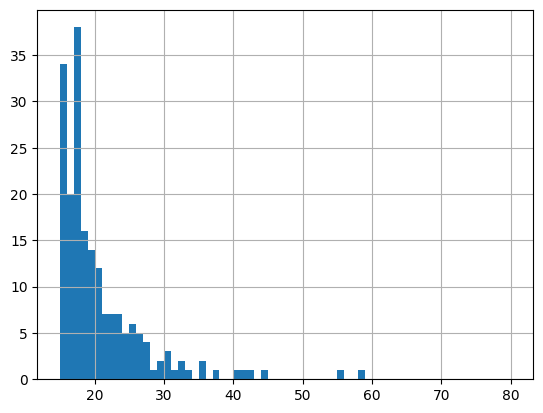

In [58]:
global dataframe

#melt down
melted = pd.melt(dataframe, id_vars='Class', value_vars=['reviewTime'] )

dataframe.plot.bar(x='reviewTime', rot=0, title='Review-Time occurrences', figsize=(10, 15), fontsize=12)

# Plot ReviewerID-Review occurrences from 2 to 10 occurrences

<AxesSubplot: >

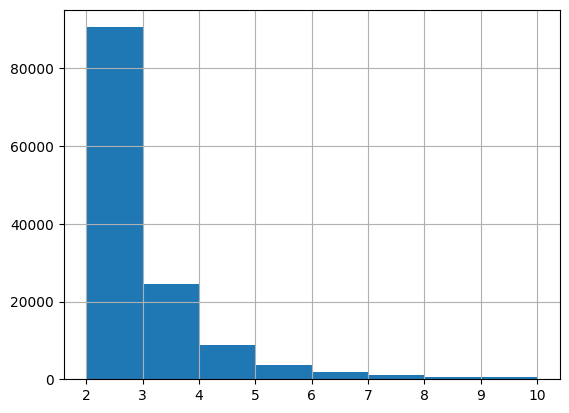

In [57]:
global dataframe

dataframe['reviewerID'].value_counts().hist(bins=8, range=[2, 10])

# Plot ReviewText length

<AxesSubplot: >

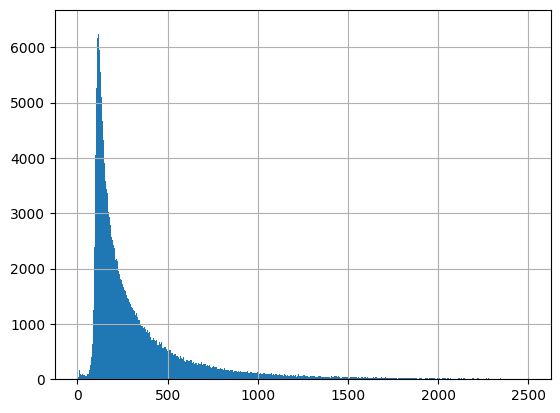

In [59]:
global dataframe

dataframe['reviewText'].str.len().hist(bins=2500, range=[0, 2500])